# Liu2024 Author-Code-Matched CSP/FBCSP Baselines

This notebook reproduces the **released Liu2024 MATLAB CSP/FBCSP validation logic** as closely as possible while keeping the Python loading code flexible.

Important distinction:

- The paper text says the quantitative decoding used 8–30 Hz data and 0–4 s after stimulus onset.
- The released MATLAB code uses marker-aligned extraction, a 50 Hz notch, a causal 4–30 Hz Butterworth bandpass, and then keeps 0–4 s after marker `2`.
- The released MATLAB FBCSP code uses five filter-bank bands: 10–13, 13–16, 16–19, 19–22, and 22–25 Hz.
- The released MATLAB evaluation is 10 repeated random 60/40 train/test splits per subject, not a true stratified 10-fold partition.


# 1. Setup

In [1]:
import json
import os
import re
import sys
import zipfile
import platform
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.io import loadmat
from scipy.signal import butter, iirnotch, lfilter

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    precision_score,
    recall_score,
)
from sklearn.svm import SVC

print(f"Python:   {sys.version.split()[0]}")
print(f"Platform: {platform.platform()}")


Python:   3.11.15
Platform: macOS-26.2-arm64-arm-64bit


# 2. Configuration

In [2]:
# Keep these paths consistent with your local project layout.
WORKING_DIR = Path.cwd().resolve().parent.parent

CONFIG = {
    # Paths
    "artifact_dir": str(WORKING_DIR / "artifacts" / "liu2024-author-code-match-csp-fbcsp"),
    "source_dir": str(WORKING_DIR / "liu2024_data" / "liu2024_figshare" / "sourcedata"),
    "source_zip_path": str(WORKING_DIR / "liu2024_data" / "liu2024_figshare" / "sourcedata.zip"),

    # Data conventions from Liu2024 source .mat files.
    "fs": 500,
    "samples_per_trial": 4000,  # 8 s at 500 Hz.
    "labels": {1: "Left", 2: "Right"},

    # Author MATLAB code alignment.
    # CSP_LDA.m and FBCSP_SVM.m concatenate trials, find marker-channel samples equal to 2,
    # extract trigger-800 : trigger-800+2799, filter that extended segment, then keep samples 801:2800.
    "marker_channel_index_0based": 32,
    "author_trigger_value": 2,
    "author_filter_segment_start_offset": -800,
    "author_filter_segment_n_samples": 2800,
    "author_epoch_start_in_filtered_segment": 800,
    "author_epoch_stop_in_filtered_segment": 2800,  # 2000 samples = 0-4 s after marker.
    "strict_marker_alignment": False,
    "fallback_trial_window_start_sample": 0,
    "fallback_trial_window_stop_sample": 2000,

    # Released MATLAB preprocessing.
    # Paper text says 8-30 Hz for quantitative analysis, but PlotAccuracy.m passes LowFreq=4, UpFreq=30.
    "notch_freq": 50,
    "notch_q": 6,
    "low_freq": 4,
    "up_freq": 30,
    "paper_reported_low_freq": 8,
    "paper_reported_up_freq": 30,
    "matlab_bandpass_order": 2,

    # Repeated 60/40 train/test evaluation.
    # The released MATLAB code uses randperm(40), train=first 24, test=last 16, repeated 10 times.
    # This is reproducible Python repeated holdout, not MATLAB-identical RNG.
    "n_repeats": 10,
    "n_train": 24,
    "n_test": 16,
    "random_state": 2026,
    "split_mode": "author_random_repeated_holdout",
    "assert_balanced_splits": False,

    # CSP/FBCSP settings from released MATLAB code.
    "csp_m": 2,
    "csp_test_log_one_plus_var": True,  # CSPFilter.m uses log(1 + var) for CSP test features.
    "fbcsp_freq_bands": [
        (10, 13), (13, 16), (16, 19), (19, 22), (22, 25),
    ],
    "fbcsp_filter_order": 4,
    "match_matlab_designfilt_total_order": True,

    # Author-style channel selection from source .mat rawdata.
    # Source data have 30 EEG channels, 2 EOG channels, and 1 marker channel.
    # Channel 18 in the paper is CPz reference and is excluded, leaving 29 EEG channels.
    "author_channel_indices_0based": [
        0, 1, 2, 3, 4, 5, 6, 7, 8, 9,
        10, 11, 12, 13, 14, 15, 16,
        18, 19, 20, 21, 22, 23, 24,
        25, 26, 27, 28, 29,
    ],
    "author_used_channel_names": [
        "Fp1", "Fp2", "Fz", "F3", "F4", "F7", "F8", "FCz", "FC3", "FC4",
        "FT7", "FT8", "Cz", "C3", "C4", "T3", "T4", "CP3", "CP4", "TP7",
        "TP8", "Pz", "P3", "P4", "T5", "T6", "Oz", "O1", "O2",
    ],

    # Paper Table 4 reference targets.
    "paper_targets": {
        "CSP_LDA": 55.57,
        "FBCSP_SVM": 57.57,
    },

    # Use one repeat for paper-scale confusion matrices; all repeats are saved separately too.
    "paper_style_confusion_repeat_id": 1,
}

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
ARTIFACT_DIR = Path(CONFIG["artifact_dir"]) / RUN_ID
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

with open(ARTIFACT_DIR / "config.json", "w") as f:
    json.dump(CONFIG, f, indent=2)

print("Artifact directory:", ARTIFACT_DIR)
print("Source dir:", CONFIG["source_dir"])
print("Source zip:", CONFIG["source_zip_path"])


Artifact directory: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/artifacts/liu2024-author-code-match-csp-fbcsp/20260521_103301
Source dir: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/liu2024_data/liu2024_figshare/sourcedata
Source zip: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/liu2024_data/liu2024_figshare/sourcedata.zip


# 3. Load Liu2024 Source MAT Data and Build Author-Code Epochs

In [3]:
def maybe_extract_source_zip(source_zip_path, source_dir):
    source_zip_path = Path(source_zip_path)
    source_dir = Path(source_dir)
    if source_dir.exists() and any(source_dir.rglob("*.mat")):
        print(f"Using existing extracted source dir: {source_dir}")
        return source_dir
    if source_zip_path.exists():
        source_dir.mkdir(parents=True, exist_ok=True)
        print(f"Extracting {source_zip_path} -> {source_dir}")
        with zipfile.ZipFile(source_zip_path, "r") as zf:
            zf.extractall(source_dir)
        return source_dir
    raise FileNotFoundError(
        "Could not find source .mat files. Update CONFIG['source_dir'] or CONFIG['source_zip_path']."
    )

def find_source_mat_files(root):
    root = Path(root)
    return sorted(root.rglob("*.mat"))

def subject_id_from_path(path):
    s = str(path)
    m = re.search(r"sub[-_ ]?(\d{1,2})", s, flags=re.IGNORECASE)
    if m:
        return int(m.group(1))
    nums = re.findall(r"\d+", Path(path).stem)
    if nums:
        return int(nums[-1])
    raise ValueError(f"Could not infer subject id from path: {path}")

def _find_key_case_insensitive(mat, target):
    for k in mat.keys():
        if k.lower() == target.lower():
            return k
    return None

def _public_mat_items(mat):
    return [(k, v) for k, v in mat.items() if not str(k).startswith("__")]

def _field_names(obj):
    if isinstance(obj, dict):
        return [k for k in obj.keys() if not str(k).startswith("__")]
    if hasattr(obj, "_fieldnames") and obj._fieldnames is not None:
        return list(obj._fieldnames)
    if isinstance(obj, np.void) and obj.dtype.names is not None:
        return list(obj.dtype.names)
    return []

def _get_field(obj, name):
    if isinstance(obj, dict):
        for k, v in obj.items():
            if str(k).lower() == name.lower():
                return v
        return None
    if hasattr(obj, "_fieldnames") and obj._fieldnames is not None:
        for k in obj._fieldnames:
            if str(k).lower() == name.lower():
                return getattr(obj, k)
        return None
    if isinstance(obj, np.void) and obj.dtype.names is not None:
        for k in obj.dtype.names:
            if str(k).lower() == name.lower():
                return obj[k]
        return None
    return None

def _find_named_value(obj, names, max_depth=4):
    names_lower = {n.lower() for n in names}

    def walk(x, depth):
        if depth > max_depth:
            return None

        for field_name in _field_names(x):
            if str(field_name).lower() in names_lower:
                return _get_field(x, field_name)

        if isinstance(x, dict):
            values = [v for k, v in x.items() if not str(k).startswith("__")]
        elif hasattr(x, "_fieldnames") and x._fieldnames is not None:
            values = [getattr(x, k) for k in x._fieldnames]
        elif isinstance(x, np.void) and x.dtype.names is not None:
            values = [x[k] for k in x.dtype.names]
        elif isinstance(x, np.ndarray) and x.dtype == object and x.size <= 25:
            values = list(x.flat)
        else:
            values = []

        for v in values:
            found = walk(v, depth + 1)
            if found is not None:
                return found
        return None

    return walk(obj, 0)

def _as_numeric_array(x):
    if x is None:
        return None
    arr = np.asarray(x)
    if arr.dtype == object:
        if arr.size == 1:
            return _as_numeric_array(arr.item())
        return None
    try:
        return np.asarray(arr, dtype=np.float64)
    except (TypeError, ValueError):
        return None

def _labels_from_candidate(candidate, n_trials):
    arr = _as_numeric_array(candidate)
    if arr is None:
        return None
    vals = np.rint(arr).astype(int).reshape(-1)
    vals = vals[np.isin(vals, [1, 2])]
    if vals.size == n_trials:
        return vals
    if vals.size > n_trials:
        return vals[:n_trials]
    return None

def _labels_from_marker_channel(raw):
    marker = np.rint(raw[:, -1, :]).astype(int)
    labels = []
    for trial_marker in marker:
        vals = trial_marker[np.isin(trial_marker, [1, 2])]
        if vals.size == 0:
            return None
        unique, counts = np.unique(vals, return_counts=True)
        labels.append(int(unique[np.argmax(counts)]))
    return np.asarray(labels, dtype=int)

def _raw_from_continuous(continuous):
    arr = _as_numeric_array(continuous)
    if arr is None or arr.ndim != 2:
        return None

    if arr.shape[0] <= 64 and arr.shape[1] > arr.shape[0]:
        arr = arr.T

    samples_per_trial = int(CONFIG["samples_per_trial"])
    n_trials = arr.shape[0] // samples_per_trial
    if n_trials <= 0:
        return None

    usable_samples = n_trials * samples_per_trial
    arr = arr[:usable_samples]
    raw = arr.reshape(n_trials, samples_per_trial, arr.shape[1]).transpose(0, 2, 1)
    return raw

def _orient_trial_tensor(raw, labels=None):
    raw = _as_numeric_array(raw)
    if raw is None or raw.ndim != 3:
        return None

    n_labels = None if labels is None else len(np.asarray(labels).reshape(-1))

    if n_labels is not None and raw.shape[0] == n_labels:
        return raw
    if n_labels is not None and raw.shape[-1] == n_labels:
        return np.moveaxis(raw, -1, 0)

    dims = list(raw.shape)
    trial_axis = int(np.argmin([abs(d - 40) for d in dims]))
    tmp = np.moveaxis(raw, trial_axis, 0)
    remaining = list(tmp.shape[1:])
    channel_axis_after_trial = 1 if remaining[0] <= remaining[1] else 2
    if channel_axis_after_trial == 2:
        tmp = np.transpose(tmp, (0, 2, 1))
    return tmp

def load_subject_mat_raw(path):
    mat = loadmat(path, squeeze_me=True, struct_as_record=False)

    raw_candidate = _find_named_value(mat, ["rawdata", "raw_data", "data"])
    labels_candidate = _find_named_value(mat, ["labels", "label", "y"])

    labels = None
    raw = None

    labels_direct = _labels_from_candidate(labels_candidate, n_trials=40)

    raw_arr = _as_numeric_array(raw_candidate)
    if raw_arr is not None and raw_arr.ndim == 3:
        raw = _orient_trial_tensor(raw_arr, labels_direct)
        labels = labels_direct
    elif raw_arr is not None and raw_arr.ndim == 2:
        raw = _raw_from_continuous(raw_arr)
        labels = labels_direct

    if raw is None:
        eeg_key = _find_key_case_insensitive(mat, "eeg")
        if eeg_key is not None:
            eeg_obj = mat[eeg_key]
            eeg_data = _find_named_value(eeg_obj, ["rawdata", "raw_data", "data"])
            eeg_arr = _as_numeric_array(eeg_data)
            if eeg_arr is None:
                eeg_arr = _as_numeric_array(eeg_obj)
            if eeg_arr is not None and eeg_arr.ndim == 3:
                raw = _orient_trial_tensor(eeg_arr, labels_direct)
            elif eeg_arr is not None and eeg_arr.ndim == 2:
                raw = _raw_from_continuous(eeg_arr)

            if labels is None:
                eeg_labels = _find_named_value(eeg_obj, ["labels", "label", "y"])
                labels = _labels_from_candidate(eeg_labels, raw.shape[0] if raw is not None else 40)

    if raw is None:
        keys = [k for k, _ in _public_mat_items(mat)]
        eeg_key = _find_key_case_insensitive(mat, "eeg")
        eeg_fields = _field_names(mat[eeg_key]) if eeg_key is not None else []
        raise KeyError(
            f"Could not extract EEG data from {path}. Top-level keys: {keys}. eeg fields: {eeg_fields}"
        )

    if labels is None:
        labels = _labels_from_marker_channel(raw)
    if labels is None:
        keys = [k for k, _ in _public_mat_items(mat)]
        eeg_key = _find_key_case_insensitive(mat, "eeg")
        eeg_fields = _field_names(mat[eeg_key]) if eeg_key is not None else []
        raise KeyError(
            f"Could not extract labels from {path}. Top-level keys: {keys}. eeg fields: {eeg_fields}"
        )

    labels = np.asarray(labels).astype(int).reshape(-1)
    if raw.shape[0] != labels.shape[0]:
        raise ValueError(f"raw/labels trial mismatch: raw={raw.shape}, labels={labels.shape} in {path}")

    return raw, labels, raw.shape

def matlab_notch_filter_trials(X, fs=None, freq=None, q=None):
    """Match NotchFilter.m: iirnotch(...), then causal filter(), over time."""
    fs = CONFIG["fs"] if fs is None else fs
    freq = CONFIG["notch_freq"] if freq is None else freq
    q = CONFIG["notch_q"] if q is None else q
    b, a = iirnotch(freq, q, fs=fs)
    return lfilter(b, a, X, axis=-1)

def matlab_butter_bandpass_filter_trials(X, low, high, fs=None, order=None):
    """Match BandpassFilter.m default: butter(order, [low high]), then causal filter()."""
    fs = CONFIG["fs"] if fs is None else fs
    order = CONFIG["matlab_bandpass_order"] if order is None else order
    b, a = butter(int(order), [low, high], btype="bandpass", fs=fs)
    return lfilter(b, a, X, axis=-1)

def _continuous_samples_by_channels(raw):
    # MATLAB code does: eeg0 = permute(rawdata, [1 3 2]); data = [data; squeeze(eeg0(t,:,:))].
    return raw.transpose(0, 2, 1).reshape(-1, raw.shape[1])

def _group_contiguous_indices(indices):
    indices = np.asarray(indices, dtype=int)
    if indices.size == 0:
        return []
    breaks = np.where(np.diff(indices) > 1)[0] + 1
    return [g for g in np.split(indices, breaks) if len(g) > 0]

def find_author_trigger_indices(raw):
    continuous = _continuous_samples_by_channels(raw)
    marker_idx = int(CONFIG["marker_channel_index_0based"])
    if marker_idx >= continuous.shape[1]:
        return np.asarray([], dtype=int), continuous
    marker = np.rint(continuous[:, marker_idx]).astype(int)
    raw_hits = np.flatnonzero(marker == int(CONFIG["author_trigger_value"]))
    groups = _group_contiguous_indices(raw_hits)
    triggers = np.asarray([int(g[0]) for g in groups], dtype=int)
    return triggers, continuous

def build_author_code_epochs(raw, labels, subject_id=None):
    """Build epochs the way CSP_LDA.m/FBCSP_SVM.m do it.

    Output X has shape trials x channels x time, with time = 2000 samples.
    """
    labels = np.asarray(labels, dtype=int).reshape(-1)
    ch_idx = list(CONFIG["author_channel_indices_0based"])

    triggers, continuous = find_author_trigger_indices(raw)
    seg_start_offset = int(CONFIG["author_filter_segment_start_offset"])
    seg_n = int(CONFIG["author_filter_segment_n_samples"])
    epoch_start = int(CONFIG["author_epoch_start_in_filtered_segment"])
    epoch_stop = int(CONFIG["author_epoch_stop_in_filtered_segment"])

    segments = []
    kept_labels = []
    skipped = []

    for trial_i, trigger in enumerate(triggers[: len(labels)]):
        start = int(trigger) + seg_start_offset
        stop = start + seg_n
        if start < 0 or stop > continuous.shape[0]:
            skipped.append((trial_i, int(trigger), start, stop))
            continue
        segment = continuous[start:stop, :][:, ch_idx].T  # channels x extended-time
        segments.append(segment)
        kept_labels.append(labels[trial_i])

    used_marker_alignment = len(segments) == len(labels)

    if not used_marker_alignment:
        message = (
            f"Subject {subject_id}: marker-aligned extraction kept {len(segments)}/{len(labels)} trials "
            f"from {len(triggers)} marker groups."
        )
        if CONFIG.get("strict_marker_alignment", False):
            raise RuntimeError(message + f" First skipped: {skipped[:3]}")
        print("WARNING:", message)
        print("         Falling back to direct stored-trial crop. This is less author-code-like.")
        start = int(CONFIG["fallback_trial_window_start_sample"])
        stop = int(CONFIG["fallback_trial_window_stop_sample"])
        X = raw[:, ch_idx, start:stop]
        X = matlab_notch_filter_trials(X)
        X = matlab_butter_bandpass_filter_trials(X, CONFIG["low_freq"], CONFIG["up_freq"])
        return X, labels, {
            "used_marker_alignment": False,
            "trigger_count": int(len(triggers)),
            "kept_trials": int(len(labels)),
            "skipped_trials": int(len(skipped)),
        }

    X_ext = np.stack(segments, axis=0)
    X_ext = matlab_notch_filter_trials(X_ext)
    X_ext = matlab_butter_bandpass_filter_trials(X_ext, CONFIG["low_freq"], CONFIG["up_freq"])
    X = X_ext[:, :, epoch_start:epoch_stop]
    y = np.asarray(kept_labels, dtype=int)

    return X, y, {
        "used_marker_alignment": True,
        "trigger_count": int(len(triggers)),
        "kept_trials": int(len(y)),
        "skipped_trials": int(len(skipped)),
    }

source_dir = maybe_extract_source_zip(CONFIG["source_zip_path"], CONFIG["source_dir"])
mat_files = find_source_mat_files(source_dir)
print(f"Total .mat files found: {len(mat_files)}")
for p in mat_files[:5]:
    print("  preview:", p)

SUBJECT_DATA = {}
for path in mat_files:
    sid = subject_id_from_path(path)
    raw, y_raw, raw_shape = load_subject_mat_raw(path)
    X, y, epoch_info = build_author_code_epochs(raw, y_raw, subject_id=sid)
    SUBJECT_DATA[sid] = {
        "X": X,
        "y": y,
        "path": str(path),
        "raw_shape": raw_shape,
        "epoch_info": epoch_info,
    }

SUBJECT_IDS = sorted(SUBJECT_DATA.keys())
print(f"Loaded subjects: {len(SUBJECT_IDS)}")
if SUBJECT_IDS:
    sid0 = SUBJECT_IDS[0]
    X0 = SUBJECT_DATA[sid0]["X"]
    y0 = SUBJECT_DATA[sid0]["y"]
    print(
        f"Example subject {sid0}: raw={SUBJECT_DATA[sid0]['raw_shape']}, "
        f"X={X0.shape}, y_counts={dict(zip(*np.unique(y0, return_counts=True)))}, "
        f"epoch_info={SUBJECT_DATA[sid0]['epoch_info']}"
    )

inventory_rows = []
for sid in SUBJECT_IDS:
    item = SUBJECT_DATA[sid]
    counts = dict(zip(*np.unique(item["y"], return_counts=True)))
    inventory_rows.append({
        "subject_id": int(sid),
        "path": item["path"],
        "raw_shape": str(tuple(item["raw_shape"])),
        "X_shape": str(tuple(item["X"].shape)),
        "label_1_left_count": int(counts.get(1, 0)),
        "label_2_right_count": int(counts.get(2, 0)),
        **item["epoch_info"],
    })

subject_inventory = pd.DataFrame(inventory_rows)
subject_inventory_path = ARTIFACT_DIR / "subject_inventory.csv"
subject_inventory.to_csv(subject_inventory_path, index=False)
print(f"Wrote subject inventory: {subject_inventory_path}")
subject_inventory.head()


Using existing extracted source dir: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/liu2024_data/liu2024_figshare/sourcedata
Total .mat files found: 50
  preview: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/liu2024_data/liu2024_figshare/sourcedata/sub-01/sub-01_task-motor-imagery_eeg.mat
  preview: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/liu2024_data/liu2024_figshare/sourcedata/sub-02/sub-02_task-motor-imagery_eeg.mat
  preview: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/liu2024_data/liu2024_figshare/sourcedata/sub-03/sub-03_task-motor-imagery_eeg.mat
  preview: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/liu2024_data/liu2024_figshare/sourcedata/sub-04/sub-04_task-motor-imagery_eeg.mat
  preview: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/liu2024_data/liu2024_figsh

,subject_id,path,raw_shape,X_shape,label_1_left_count,label_2_right_count,used_marker_alignment,trigger_count,kept_trials,skipped_trials
0,1,/Users/vadim/Documents/School/Spring 2026/CSCE...,"(40, 33, 4000)","(40, 29, 2000)",20,20,True,40,40,0
1,2,/Users/vadim/Documents/School/Spring 2026/CSCE...,"(40, 33, 4000)","(40, 29, 2000)",20,20,True,40,40,0
2,3,/Users/vadim/Documents/School/Spring 2026/CSCE...,"(40, 33, 4000)","(40, 29, 2000)",20,20,True,40,40,0
3,4,/Users/vadim/Documents/School/Spring 2026/CSCE...,"(40, 33, 4000)","(40, 29, 2000)",20,20,True,40,40,0
4,5,/Users/vadim/Documents/School/Spring 2026/CSCE...,"(40, 33, 4000)","(40, 29, 2000)",20,20,True,40,40,0


# 4. Author-Code-Matched CSP and FBCSP Methods

In [4]:
def matlab_designfilt_bandpass_trials(X, low, high, fs=None, filter_order=None):
    """Approximate MATLAB designfilt('bandpassiir','FilterOrder',4,...) + filter()."""
    fs = CONFIG["fs"] if fs is None else fs
    filter_order = CONFIG["fbcsp_filter_order"] if filter_order is None else filter_order
    if CONFIG.get("match_matlab_designfilt_total_order", True):
        # scipy butter(N, bandpass) creates a 2N total-order bandpass.
        # MATLAB designfilt FilterOrder=4 is closest to scipy butter N=2 here.
        scipy_order = max(1, int(filter_order) // 2)
    else:
        scipy_order = int(filter_order)
    b, a = butter(scipy_order, [low, high], btype="bandpass", fs=fs)
    return lfilter(b, a, X, axis=-1)

def _trial_covariance_author(trial):
    # MATLAB CSP.m uses E = eeg(:,:,i)' where E is channels x time, then E*E'/trace.
    cov = trial @ trial.T
    tr = np.trace(cov)
    if tr <= 0 or not np.isfinite(tr):
        return cov
    return cov / tr

def fit_csp_filters_author(X_train, y_train, m=2):
    """Match the whitening/eigendecomposition logic in Liu CSP.m."""
    y_train = np.asarray(y_train, dtype=int)
    class_labels = np.unique(y_train)
    if len(class_labels) != 2:
        raise ValueError(f"CSP expects exactly two classes, got {class_labels}")

    cov_mats = []
    for cls in class_labels:
        cls_trials = X_train[y_train == cls]
        trial_cov = np.stack([_trial_covariance_author(trial) for trial in cls_trials], axis=0)
        cov_mats.append(np.mean(trial_cov, axis=0))

    cov1, cov2 = cov_mats
    cov_total = cov1 + cov2

    eigvals, eigvecs = np.linalg.eig(cov_total)
    eigvals = np.real(eigvals)
    eigvecs = np.real(eigvecs)
    order = np.argsort(eigvals)[::-1]
    eigvals = np.maximum(eigvals[order], 1e-12)
    Ut = eigvecs[:, order]

    P = np.diag(np.sqrt(1.0 / eigvals)) @ Ut.T
    transformed_cov1 = P @ cov1 @ P.T

    eigvals1, U1 = np.linalg.eig(transformed_cov1)
    eigvals1 = np.real(eigvals1)
    U1 = np.real(U1)
    order1 = np.argsort(eigvals1)[::-1]
    U1 = U1[:, order1]

    csp_matrix = U1.T @ P
    selected = list(range(m)) + list(range(csp_matrix.shape[0] - m, csp_matrix.shape[0]))
    return csp_matrix[selected, :]

def transform_csp_features_author(X, W, add_one=False):
    projected = np.asarray([W @ trial for trial in X])
    variances = np.var(projected, axis=-1, ddof=1)
    variances = np.maximum(variances, 1e-12)
    if add_one:
        return np.log1p(variances)
    return np.log(variances)

def run_csp_lda(X_train, y_train, X_test, y_test):
    # X has already been marker-aligned, notched, 4-30 Hz filtered, and cropped to 0-4 s.
    W = fit_csp_filters_author(X_train, y_train, m=int(CONFIG["csp_m"]))
    F_train = transform_csp_features_author(X_train, W, add_one=False)
    F_test = transform_csp_features_author(
        X_test,
        W,
        add_one=bool(CONFIG.get("csp_test_log_one_plus_var", True)),
    )
    clf = LinearDiscriminantAnalysis()
    clf.fit(F_train, y_train)
    y_pred = clf.predict(F_test)
    return y_pred, F_train.shape[1]

def run_fbcsp_svm(X_train, y_train, X_test, y_test):
    train_features = []
    test_features = []
    for low, high in CONFIG["fbcsp_freq_bands"]:
        X_train_f = matlab_designfilt_bandpass_trials(
            X_train,
            low,
            high,
            CONFIG["fs"],
            CONFIG["fbcsp_filter_order"],
        )
        X_test_f = matlab_designfilt_bandpass_trials(
            X_test,
            low,
            high,
            CONFIG["fs"],
            CONFIG["fbcsp_filter_order"],
        )
        W = fit_csp_filters_author(X_train_f, y_train, m=int(CONFIG["csp_m"]))
        train_features.append(transform_csp_features_author(X_train_f, W, add_one=False))
        test_features.append(transform_csp_features_author(X_test_f, W, add_one=False))

    F_train = np.concatenate(train_features, axis=1)
    F_test = np.concatenate(test_features, axis=1)

    # MATLAB uses fitcecoc(train_feature, label_train). For the binary case this is closest to a default linear SVM.
    clf = SVC(kernel="linear", C=1.0)
    clf.fit(F_train, y_train)
    y_pred = clf.predict(F_test)
    return y_pred, F_train.shape[1]


# 5. Author Repeated 60/40 Evaluation

In [5]:
def _class_count_dict(y_values):
    keys, vals = np.unique(y_values, return_counts=True)
    return {int(k): int(v) for k, v in zip(keys, vals)}

def make_author_repeat_split(y, subject_id, repeat_id):
    """Match the released MATLAB split structure: randperm(40), first 24 train, last 16 test.

    This intentionally does not stratify. A fixed Python seed is used for reproducibility,
    so the random splits will not be byte-identical to MATLAB randperm but follow the same design.
    """
    y = np.asarray(y).astype(int)
    n_trials = len(y)
    n_train = int(CONFIG["n_train"])
    n_test = int(CONFIG["n_test"])
    if n_train + n_test > n_trials:
        raise ValueError(f"Requested {n_train}+{n_test} split from only {n_trials} trials.")

    seed = int(CONFIG["random_state"]) + int(subject_id) * 1000 + int(repeat_id)
    rng = np.random.default_rng(seed)
    perm = rng.permutation(np.arange(n_trials))
    train_idx = perm[:n_train]
    test_idx = perm[n_train:n_train + n_test]
    return np.asarray(train_idx), np.asarray(test_idx)

def evaluate_prediction(y_test, y_pred):
    labels_standard = [1, 2]
    labels_author = [2, 1]  # paper figure order: Right Hand, Left Hand

    cm_standard = confusion_matrix(y_test, y_pred, labels=labels_standard)
    cm_author = confusion_matrix(y_test, y_pred, labels=labels_author)
    pred_values, pred_counts = np.unique(y_pred, return_counts=True)

    return {
        "accuracy": float(accuracy_score(y_test, y_pred) * 100.0),
        "balanced_accuracy": float(balanced_accuracy_score(y_test, y_pred) * 100.0),
        "kappa_sklearn": float(cohen_kappa_score(y_test, y_pred, labels=labels_standard)),
        "precision_macro": float(precision_score(y_test, y_pred, labels=labels_standard, average="macro", zero_division=0) * 100.0),
        "sensitivity_macro": float(recall_score(y_test, y_pred, labels=labels_standard, average="macro", zero_division=0) * 100.0),
        "prediction_counts": {int(k): int(v) for k, v in zip(pred_values, pred_counts)},
        "confusion_matrix_standard_labels_1_2": cm_standard.tolist(),
        "confusion_matrix_author_labels_2_1": cm_author.tolist(),
        "left_total": int(np.sum(y_test == 1)),
        "left_correct": int(np.sum((y_test == 1) & (y_pred == 1))),
        "right_total": int(np.sum(y_test == 2)),
        "right_correct": int(np.sum((y_test == 2) & (y_pred == 2))),
    }

def run_subject(subject_id, X, y):
    rows = []
    for repeat_id in range(1, int(CONFIG["n_repeats"]) + 1):
        train_idx, test_idx = make_author_repeat_split(y, subject_id, repeat_id)
        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx], y[test_idx]

        train_counts = _class_count_dict(y_train)
        test_counts = _class_count_dict(y_test)

        for method_name, fn in [
            ("CSP_LDA", run_csp_lda),
            ("FBCSP_SVM", run_fbcsp_svm),
        ]:
            y_pred, n_features = fn(X_train, y_train, X_test, y_test)
            metrics = evaluate_prediction(y_test, y_pred)
            rows.append({
                "subject_id": int(subject_id),
                "repeat_id": int(repeat_id),
                "method_name": method_name,
                "window_name": "marker_aligned_0_4s_after_trigger_2",
                "window_start_sample": int(CONFIG["author_epoch_start_in_filtered_segment"]),
                "window_stop_sample": int(CONFIG["author_epoch_stop_in_filtered_segment"]),
                "n_train": int(len(train_idx)),
                "n_test": int(len(test_idx)),
                "n_channels": int(X.shape[1]),
                "n_times": int(X.shape[2]),
                "train_indices_0based": train_idx.tolist(),
                "test_indices_0based": test_idx.tolist(),
                "train_class_counts": train_counts,
                "test_class_counts": test_counts,
                "n_features": int(n_features),
                **metrics,
            })
    return rows

primary_window_name = "marker_aligned_0_4s_after_trigger_2"
primary_start = int(CONFIG["author_epoch_start_in_filtered_segment"])
primary_stop = int(CONFIG["author_epoch_stop_in_filtered_segment"])
print(f"Primary evaluation window: {primary_window_name} = filtered-segment samples {primary_start}:{primary_stop}")
print(f"Split mode: {CONFIG['split_mode']} | n_repeats={CONFIG['n_repeats']} | n_train={CONFIG['n_train']} | n_test={CONFIG['n_test']}")

FOLD_ROWS = []
for subject_id in SUBJECT_IDS:
    X = SUBJECT_DATA[subject_id]["X"]
    y = SUBJECT_DATA[subject_id]["y"]

    counts = _class_count_dict(y)
    print(f"Subject {subject_id:02d}: X={X.shape}, y_counts={counts}, epoch_info={SUBJECT_DATA[subject_id]['epoch_info']}")
    subject_rows = run_subject(subject_id, X, y)
    FOLD_ROWS.extend(subject_rows)
    subject_df = pd.DataFrame(subject_rows)
    for method_name in ["CSP_LDA", "FBCSP_SVM"]:
        mean_acc = subject_df.loc[subject_df["method_name"] == method_name, "accuracy"].mean()
        print(f"  {method_name}: mean repeat accuracy = {mean_acc:.2f}%")

fold_df = pd.DataFrame(FOLD_ROWS)
fold_path = ARTIFACT_DIR / "fold_level_results.csv"
fold_df.to_csv(fold_path, index=False)
print(f"Wrote fold-level results: {fold_path}")

if CONFIG.get("assert_balanced_splits", False):
    expected_train = {1: int(CONFIG["n_train"]) // 2, 2: int(CONFIG["n_train"]) // 2}
    expected_test = {1: int(CONFIG["n_test"]) // 2, 2: int(CONFIG["n_test"]) // 2}
    bad_rows = []
    for _, row in fold_df.iterrows():
        train_counts = row["train_class_counts"]
        test_counts = row["test_class_counts"]
        if isinstance(train_counts, str):
            train_counts = json.loads(train_counts.replace("'", '"'))
        if isinstance(test_counts, str):
            test_counts = json.loads(test_counts.replace("'", '"'))
        train_counts = {int(k): int(v) for k, v in dict(train_counts).items()}
        test_counts = {int(k): int(v) for k, v in dict(test_counts).items()}
        if train_counts != expected_train or test_counts != expected_test:
            bad_rows.append((row["subject_id"], row["repeat_id"], row["method_name"], train_counts, test_counts))
    if bad_rows:
        raise AssertionError(f"Found unbalanced saved split rows. First examples: {bad_rows[:5]}")
    print(f"Balanced split verification passed for {len(fold_df)} method rows.")
else:
    split_check = (
        fold_df.groupby(["method_name", "subject_id", "repeat_id"])
        .agg(train_class_counts=("train_class_counts", "first"), test_class_counts=("test_class_counts", "first"))
        .reset_index()
    )
    split_check_path = ARTIFACT_DIR / "author_random_split_class_counts.csv"
    split_check.to_csv(split_check_path, index=False)
    print(f"Saved non-stratified author-style split class counts: {split_check_path}")


Primary evaluation window: marker_aligned_0_4s_after_trigger_2 = filtered-segment samples 800:2800
Split mode: author_random_repeated_holdout | n_repeats=10 | n_train=24 | n_test=16
Subject 01: X=(40, 29, 2000), y_counts={1: 20, 2: 20}, epoch_info={'used_marker_alignment': True, 'trigger_count': 40, 'kept_trials': 40, 'skipped_trials': 0}
  CSP_LDA: mean repeat accuracy = 49.38%
  FBCSP_SVM: mean repeat accuracy = 48.12%
Subject 02: X=(40, 29, 2000), y_counts={1: 20, 2: 20}, epoch_info={'used_marker_alignment': True, 'trigger_count': 40, 'kept_trials': 40, 'skipped_trials': 0}
  CSP_LDA: mean repeat accuracy = 42.50%
  FBCSP_SVM: mean repeat accuracy = 39.38%
Subject 03: X=(40, 29, 2000), y_counts={1: 20, 2: 20}, epoch_info={'used_marker_alignment': True, 'trigger_count': 40, 'kept_trials': 40, 'skipped_trials': 0}
  CSP_LDA: mean repeat accuracy = 44.38%
  FBCSP_SVM: mean repeat accuracy = 43.75%
Subject 04: X=(40, 29, 2000), y_counts={1: 20, 2: 20}, epoch_info={'used_marker_alignment

# 6. Time-Window Diagnostic Sweep

In [6]:
# In the previous version of this notebook, this section swept stored-trial windows like 0-4, 1-5, 2-6 s.
# That is useful for diagnostics, but it is not the released Liu MATLAB CSP/FBCSP procedure.
# The author-code-matched path above is marker-aligned and therefore disables the sweep by default.

window_sweep_plot_path = None
window_sweep_fold_path = None
window_sweep_subject_path = None
window_sweep_method_path = None

print("Time-window sweep disabled in the author-code-matched notebook.")
print("For S-JEPA-compatible preprocessing/window experiments, use the separate S-JEPA CSP/FBCSP sanity-baseline notebook.")


Time-window sweep disabled in the author-code-matched notebook.
For S-JEPA-compatible preprocessing/window experiments, use the separate S-JEPA CSP/FBCSP sanity-baseline notebook.


# 7. Aggregate Metrics

In [7]:

def aggregate_outputs(fold_df):
    subject_summary = (
        fold_df.groupby(["method_name", "subject_id"], as_index=False)
        .agg(
            mean_accuracy=("accuracy", "mean"),
            std_accuracy=("accuracy", "std"),
            mean_balanced_accuracy=("balanced_accuracy", "mean"),
            mean_kappa_sklearn=("kappa_sklearn", "mean"),
            n_repeats=("repeat_id", "nunique"),
            left_total=("left_total", "sum"),
            left_correct=("left_correct", "sum"),
            right_total=("right_total", "sum"),
            right_correct=("right_correct", "sum"),
        )
    )

    method_summary = (
        subject_summary.groupby("method_name", as_index=False)
        .agg(
            mean_accuracy=("mean_accuracy", "mean"),
            std_accuracy=("mean_accuracy", "std"),
            mean_balanced_accuracy=("mean_balanced_accuracy", "mean"),
            mean_kappa_sklearn=("mean_kappa_sklearn", "mean"),
            n_subjects=("subject_id", "nunique"),
        )
    )
    method_summary["paper_target_accuracy"] = method_summary["method_name"].map(CONFIG["paper_targets"])
    method_summary["delta_vs_paper"] = method_summary["mean_accuracy"] - method_summary["paper_target_accuracy"]

    return subject_summary, method_summary

subject_summary, method_summary = aggregate_outputs(fold_df)

subject_summary_path = ARTIFACT_DIR / "subject_level_summary.csv"
method_summary_path = ARTIFACT_DIR / "global_method_comparison.csv"
subject_summary.to_csv(subject_summary_path, index=False)
method_summary.to_csv(method_summary_path, index=False)

print("\nMethod-level summary")
print(method_summary.to_string(index=False))
print(f"\nWrote subject summary: {subject_summary_path}")
print(f"Wrote method summary:  {method_summary_path}")


Method-level summary
method_name  mean_accuracy  std_accuracy  mean_balanced_accuracy  mean_kappa_sklearn  n_subjects  paper_target_accuracy  delta_vs_paper
    CSP_LDA        50.9125     11.651160               53.063696            0.058605          50                  55.57         -4.6575
  FBCSP_SVM        48.2125      9.076463               51.135819            0.022960          50                  57.57         -9.3575

Wrote subject summary: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/artifacts/liu2024-author-code-match-csp-fbcsp/20260521_103301/subject_level_summary.csv
Wrote method summary:  /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/artifacts/liu2024-author-code-match-csp-fbcsp/20260521_103301/global_method_comparison.csv


# 8. Author-Style Confusion Matrices

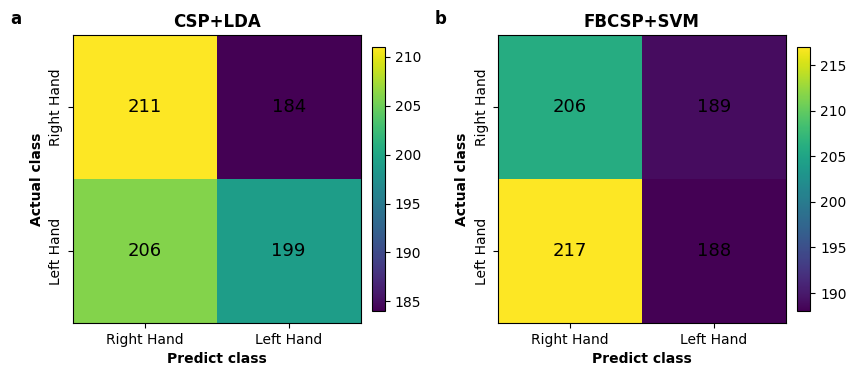

Wrote paper-style confusion matrix plot: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/artifacts/liu2024-author-code-match-csp-fbcsp/20260521_103301/paper_like_confusion_matrices_csp_fbcsp.png
Wrote paper-style confusion metrics:     /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/artifacts/liu2024-author-code-match-csp-fbcsp/20260521_103301/paper_like_confusion_metrics.csv


,method_name,repeat_id_used_for_paper_scale,author_style_confusion_matrix_right_left_order,n_predictions,accuracy_from_matrix
0,CSP_LDA,1,"[[211, 184], [206, 199]]",800,51.25
1,FBCSP_SVM,1,"[[206, 189], [217, 188]]",800,49.25


In [8]:

def _parse_matrix(value):
    if isinstance(value, list):
        return np.asarray(value, dtype=int)
    if isinstance(value, np.ndarray):
        return value.astype(int)
    return np.asarray(json.loads(value), dtype=int)

def aggregate_confusion_matrix(df, method_name, author_order=True):
    col = "confusion_matrix_author_labels_2_1" if author_order else "confusion_matrix_standard_labels_1_2"
    mats = [_parse_matrix(v) for v in df.loc[df["method_name"] == method_name, col]]
    return np.sum(mats, axis=0).astype(int)

def plot_author_style_confusion_matrices(fold_df):
    repeat_id = int(CONFIG["paper_style_confusion_repeat_id"])
    paper_df = fold_df[fold_df["repeat_id"] == repeat_id].copy()
    if paper_df.empty:
        raise ValueError(f"No rows found for repeat_id={repeat_id}")

    methods = [("CSP_LDA", "CSP+LDA"), ("FBCSP_SVM", "FBCSP+SVM")]
    fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.8), constrained_layout=True)

    paper_like_rows = []
    for ax, (method_name, title), panel in zip(axes, methods, ["a", "b"]):
        cm = aggregate_confusion_matrix(paper_df, method_name, author_order=True)
        im = ax.imshow(cm)

        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.set_xlabel("Predict class", fontweight="bold")
        ax.set_ylabel("Actual class", fontweight="bold")
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Right Hand", "Left Hand"])
        ax.set_yticks([0, 1])
        ax.set_yticklabels(["Right Hand", "Left Hand"], rotation=90, va="center")
        ax.text(-0.22, 1.04, panel, transform=ax.transAxes, fontsize=12, fontweight="bold")

        for i in range(2):
            for j in range(2):
                ax.text(j, i, str(int(cm[i, j])), ha="center", va="center", fontsize=13)

        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        paper_like_rows.append({
            "method_name": method_name,
            "repeat_id_used_for_paper_scale": repeat_id,
            "author_style_confusion_matrix_right_left_order": cm.tolist(),
            "n_predictions": int(cm.sum()),
            "accuracy_from_matrix": float((cm[0, 0] + cm[1, 1]) / cm.sum() * 100.0),
        })

    out_path = ARTIFACT_DIR / "paper_like_confusion_matrices_csp_fbcsp.png"
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()

    paper_like_df = pd.DataFrame(paper_like_rows)
    paper_like_path = ARTIFACT_DIR / "paper_like_confusion_metrics.csv"
    paper_like_df.to_csv(paper_like_path, index=False)
    print(f"Wrote paper-style confusion matrix plot: {out_path}")
    print(f"Wrote paper-style confusion metrics:     {paper_like_path}")
    return paper_like_df

paper_like_confusion_df = plot_author_style_confusion_matrices(fold_df)
paper_like_confusion_df

# 9. Subject-Level Paper-Style Accuracy Plot

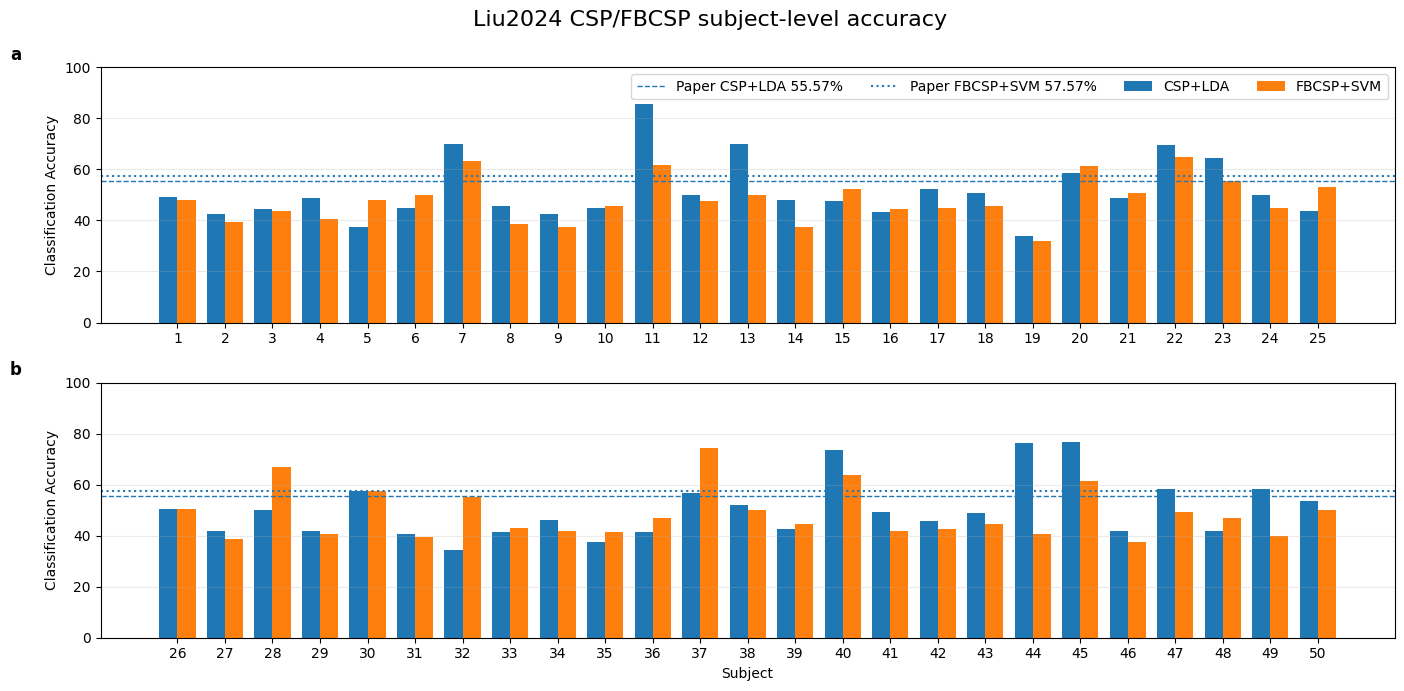

Wrote subject-level paper-style plot: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/artifacts/liu2024-author-code-match-csp-fbcsp/20260521_103301/liu2024_csp_fbcsp_subject_bars_paper_style.png


In [9]:

def plot_subject_accuracy_paper_style(subject_summary):
    df = subject_summary[subject_summary["method_name"].isin(["CSP_LDA", "FBCSP_SVM"])].copy()
    wide = df.pivot(index="subject_id", columns="method_name", values="mean_accuracy").sort_index()

    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharey=True)
    for ax, subject_ids, panel_label in [
        (axes[0], list(range(1, 26)), "a"),
        (axes[1], list(range(26, 51)), "b"),
    ]:
        available_ids = [sid for sid in subject_ids if sid in wide.index]
        data = wide.loc[available_ids]
        x = np.arange(len(data))
        width = 0.38

        ax.bar(x - width / 2, data["CSP_LDA"], width, label="CSP+LDA")
        ax.bar(x + width / 2, data["FBCSP_SVM"], width, label="FBCSP+SVM")

        ax.axhline(
            CONFIG["paper_targets"]["CSP_LDA"],
            linestyle="--",
            linewidth=1,
            label="Paper CSP+LDA 55.57%" if panel_label == "a" else None,
        )
        ax.axhline(
            CONFIG["paper_targets"]["FBCSP_SVM"],
            linestyle=":",
            linewidth=1.5,
            label="Paper FBCSP+SVM 57.57%" if panel_label == "a" else None,
        )

        ax.set_ylim(0, 100)
        ax.set_ylabel("Classification Accuracy")
        ax.set_xticks(x)
        ax.set_xticklabels(available_ids)
        ax.grid(axis="y", alpha=0.25)
        ax.text(-0.07, 1.03, panel_label, transform=ax.transAxes, fontweight="bold", fontsize=12)

    axes[0].legend(loc="upper right", ncol=4, frameon=True)
    axes[1].set_xlabel("Subject")
    fig.suptitle("Liu2024 CSP/FBCSP subject-level accuracy", fontsize=16)
    fig.tight_layout()

    out_path = ARTIFACT_DIR / "liu2024_csp_fbcsp_subject_bars_paper_style.png"
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Wrote subject-level paper-style plot: {out_path}")
    return out_path

subject_plot_path = plot_subject_accuracy_paper_style(subject_summary)

# 10. Save Metadata

In [10]:
run_metadata = {
    "run_id": RUN_ID,
    "artifact_dir": str(ARTIFACT_DIR),
    "n_subjects": int(len(SUBJECT_IDS)),
    "subjects": [int(s) for s in SUBJECT_IDS],
    "n_repeats": int(CONFIG["n_repeats"]),
    "split_mode": CONFIG["split_mode"],
    "split_note": "Released MATLAB code uses randperm(40), first 24 train and last 16 test, repeated 10 times; this notebook uses reproducible Python RNG with the same repeated-holdout design.",
    "preprocessing_match": {
        "marker_alignment": "Find marker channel == 2 after concatenating stored trials; extract trigger-800 : trigger-800+2799; filter extended segment; keep 801:2800 MATLAB samples / 0-4 s after marker.",
        "notch": f"{CONFIG['notch_freq']} Hz iirnotch with Q={CONFIG['notch_q']}, causal lfilter.",
        "common_bandpass": f"{CONFIG['low_freq']}-{CONFIG['up_freq']} Hz Butterworth order {CONFIG['matlab_bandpass_order']}, causal lfilter. Paper text reports 8-30 Hz, but PlotAccuracy.m passes 4-30 Hz.",
        "fbcsp_bands": CONFIG["fbcsp_freq_bands"],
    },
    "subject_inventory": str(subject_inventory_path),
    "confusion_matrix_fix": "Paper-style confusion plot uses one repeat across subjects to avoid 10x overcounting; all-repeat aggregate is available in fold_level_results.csv.",
    "subject_plot": str(subject_plot_path),
    "primary_trial_window": {
        "name": str(primary_window_name),
        "start_sample_in_filtered_segment": int(primary_start),
        "stop_sample_in_filtered_segment": int(primary_stop),
        "n_times": int(primary_stop - primary_start),
    },
    "window_sweep_outputs": {
        "fold_level_results": None if window_sweep_fold_path is None else str(window_sweep_fold_path),
        "subject_level_summary": None if window_sweep_subject_path is None else str(window_sweep_subject_path),
        "method_summary": None if window_sweep_method_path is None else str(window_sweep_method_path),
        "plot": None if window_sweep_plot_path is None else str(window_sweep_plot_path),
    },
    "outputs": {
        "fold_level_results": str(ARTIFACT_DIR / "fold_level_results.csv"),
        "subject_level_summary": str(ARTIFACT_DIR / "subject_level_summary.csv"),
        "global_method_comparison": str(ARTIFACT_DIR / "global_method_comparison.csv"),
        "paper_like_confusion_plot": str(ARTIFACT_DIR / "paper_like_confusion_matrices_csp_fbcsp.png"),
        "subject_accuracy_plot": str(subject_plot_path),
        "window_sweep_method_summary": None if window_sweep_method_path is None else str(window_sweep_method_path),
        "time_window_sweep_plot": None if window_sweep_plot_path is None else str(window_sweep_plot_path),
    },
}

metadata_path = ARTIFACT_DIR / "run_metadata.json"
with open(metadata_path, "w") as f:
    json.dump(run_metadata, f, indent=2)

print(f"Run metadata saved to: {metadata_path}")
print(f"All artifacts in: {ARTIFACT_DIR}")


Run metadata saved to: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/artifacts/liu2024-author-code-match-csp-fbcsp/20260521_103301/run_metadata.json
All artifacts in: /Users/vadim/Documents/School/Spring 2026/CSCE A698 Individual Research/EEG_JEPA/artifacts/liu2024-author-code-match-csp-fbcsp/20260521_103301
